# License Plate Recognition

@misc{
license-plate-recognition-rxg4e_dataset,
title = { License Plate Recognition Dataset },
type = { Open Source Dataset },
author = { Roboflow Universe Projects },
howpublished = { \url{ https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e } },
url = { https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e },
journal = { Roboflow Universe },
publisher = { Roboflow },
year = { 2024 },
month = { oct },
note = { visited on 2025-02-17 },
}

## Imports

In [1]:
# Go to project root folder
import os
os.chdir("../")
%pwd

'/workspaces/license-plate-recognition'

In [2]:
from tqdm.notebook import tqdm

from dotenv import load_dotenv
load_dotenv()

import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
tf.config.list_physical_devices('GPU'), tf.__version__

([PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')], '2.15.1')

In [3]:
# import the label map utility module
from object_detection.utils import label_map_util

# import module for reading and updating configuration files.
from object_detection.utils import config_util

# import module for visualization. use the alias `viz_utils`
from object_detection.utils import visualization_utils as viz_utils

# import module for building the detection model
from object_detection.builders import model_builder

In [4]:
%matplotlib inline
# auto reload dotenv 
%load_ext dotenv
%dotenv

# auto reload libs
%load_ext autoreload
%autoreload 2

In [5]:
!pwd

/workspaces/license-plate-recognition


In [6]:
from myutils.visualization_funcs import plot_random_images_bbox
from myutils.annotation_processor import AnnotationProcessor

## Paths Setup

In [7]:
from hydra import initialize, compose

# https://gist.github.com/bdsaglam/586704a98336a0cf0a65a6e7c247d248

with initialize(version_base=None, config_path="../conf"):
    cfg = compose(config_name="config")
    print(cfg.DATASET_DIRS.TRAIN_DIR)

datasets/car-plate-detection


In [8]:
cfg.DATASET_DIRS

{'TRAIN_DIR': '${DATASET.DATASET_DIR}/${DATASET.DATASET_NAME}', 'VALIDATION_DIR': '${DATASET.DATASET_DIR}/${DATASET.DATASET_NAME}/valid', 'TEST_DIR': '${DATASET.DATASET_DIR}/${DATASET.DATASET_NAME}/test'}

In [9]:
from pathlib import Path

DATASET_DIRS = Path(cfg.DATASET.DATASET_DIR)
DATASET_DIRS.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = DATASET_DIRS / 'car-plate-detection'
TRAIN_IMG_DIR = DATASET_DIRS /'car-plate-detection'/'images'


IMG_SIZE = cfg.TRAIN.IMG_SIZE
BATCH_SIZE = cfg.TRAIN.BATCH_SIZE

XML_ANNOT_DIR_PATH = TRAIN_DIR / 'annotations'
XML_ANNOT_DIR_PATH

PosixPath('datasets/car-plate-detection/annotations')

In [10]:
def plot_detections(image_np,
                    boxes,
                    classes,
                    scores,
                    category_index,
                    figsize=(12, 16),
                    image_name=None):
    """Wrapper function to visualize detections.

    Args:
    image_np: uint8 numpy array with shape (img_height, img_width, 3)
    boxes: a numpy array of shape [N, 4]
    classes: a numpy array of shape [N]. Note that class indices are 1-based,
          and match the keys in the label map.
    scores: a numpy array of shape [N] or None.  If scores=None, then
          this function assumes that the boxes to be plotted are groundtruth
          boxes and plot all boxes as black with no classes or scores.
    category_index: a dict containing category dictionaries (each holding
          category index `id` and category name `name`) keyed by category indices.
    figsize: size for the figure.
    image_name: a name for the image file.
    """

    image_np_with_annotations = image_np.copy()

    viz_utils.visualize_boxes_and_labels_on_image_array(
        image_np_with_annotations,
        boxes,
        classes,
        scores,
        category_index,
        use_normalized_coordinates=True,
        min_score_thresh=0.8,
        groundtruth_box_visualization_color='Red')

    if image_name:
        plt.imsave(image_name, image_np_with_annotations)

    else:
        plt.imshow(image_np_with_annotations)

## Dataset Download from Roboflow

In [11]:
DATASET_DIRS

PosixPath('datasets')

In [12]:
if len(list(DATASET_DIRS.iterdir())) == 0:
    import opendatasets as od
    od.download('https://www.kaggle.com/datasets/andrewmvd/car-plate-detection/data', data_dir=str(DATASET_DIRS))

                

## Load images from directory

In [13]:
# Assign the license plate class ID
class_id = 1

# define a dictionary describing license plate class
category_index = {class_id :
{'id'  : class_id,
 'name': 'License_Plate'}
}

# Specify the number of classes that the model will predict
num_classes = 1

In [14]:
label_map = {
    'licence':1
}

prepare_train_dataset = AnnotationProcessor(annotation_file= XML_ANNOT_DIR_PATH)

ragged_images, ragged_classes, ragged_boxes  = prepare_train_dataset.process_annotations_xml(image_dir=TRAIN_IMG_DIR, label_map=label_map)

  0%|          | 1/200 [00:00<00:32,  6.06it/s]

100%|██████████| 200/200 [00:01<00:00, 107.33it/s]


In [15]:
ragged_boxes

[array([[0.5875   , 0.4451827, 0.615    , 0.5614618]], dtype=float32),
 array([[0.31460676, 0.56      , 0.44194758, 0.6775    ]], dtype=float32),
 array([[0.6758893, 0.67     , 0.7509881, 0.785    ]], dtype=float32),
 array([[0.68108106, 0.105     , 0.74054056, 0.215     ]], dtype=float32),
 array([[0.7396907, 0.6213018, 0.8015464, 0.8027613]], dtype=float32),
 array([[0.5785124 , 0.1525    , 0.69008267, 0.2875    ]], dtype=float32),
 array([[0.31666666, 0.0125    , 0.6472222 , 0.9791667 ]], dtype=float32),
 array([[0.54     , 0.81     , 0.5833333, 0.9375   ]], dtype=float32),
 array([[0.70037454, 0.3       , 0.82397   , 0.8125    ]], dtype=float32),
 array([[0.5692884, 0.825    , 0.670412 , 0.915    ]], dtype=float32),
 array([[0.5233333, 0.3325   , 0.64     , 0.6525   ]], dtype=float32),
 array([[0.65816325, 0.575     , 0.68367344, 0.62      ],
        [0.59183675, 0.4725    , 0.61734694, 0.505     ]], dtype=float32),
 array([[0.48857144, 0.36610168, 0.5942857 , 0.6220339 ]], dtype=f

In [16]:
len(ragged_classes)

200

[[0.49596775 0.33       0.6451613  0.6525    ]]
[[0.6720648 0.385     0.757085  0.6025   ]]
[[0.6756757  0.37556562 0.7387387  0.61764705]]
[[0.39072847 0.475      0.50993377 0.6425    ]]
[[0.5300752  0.655      0.60150373 0.795     ]]
[[0.5532787 0.045     0.6229508 0.12     ]]
[[0.09666666 0.038      0.81666666 0.994     ]]
[[0.70666665 0.7075     0.74666667 0.765     ]
 [0.6666667  0.2575     0.7022222  0.305     ]]
[[0.43703705 0.30997878 0.6296296  0.6602972 ]]
[[0.62       0.275      0.69666666 0.405     ]]
[[0.5146667 0.406     0.6106667 0.57     ]]
[[0.47683924 0.415      0.5640327  0.5875    ]]
[[0.50537634 0.415      0.5519713  0.515     ]]
[[0.7844037  0.235      0.95412844 0.5275    ]]
[[0.4344569  0.2875     0.58426964 0.69      ]]
[[0.37666667 0.37       0.5933333  0.7625    ]]


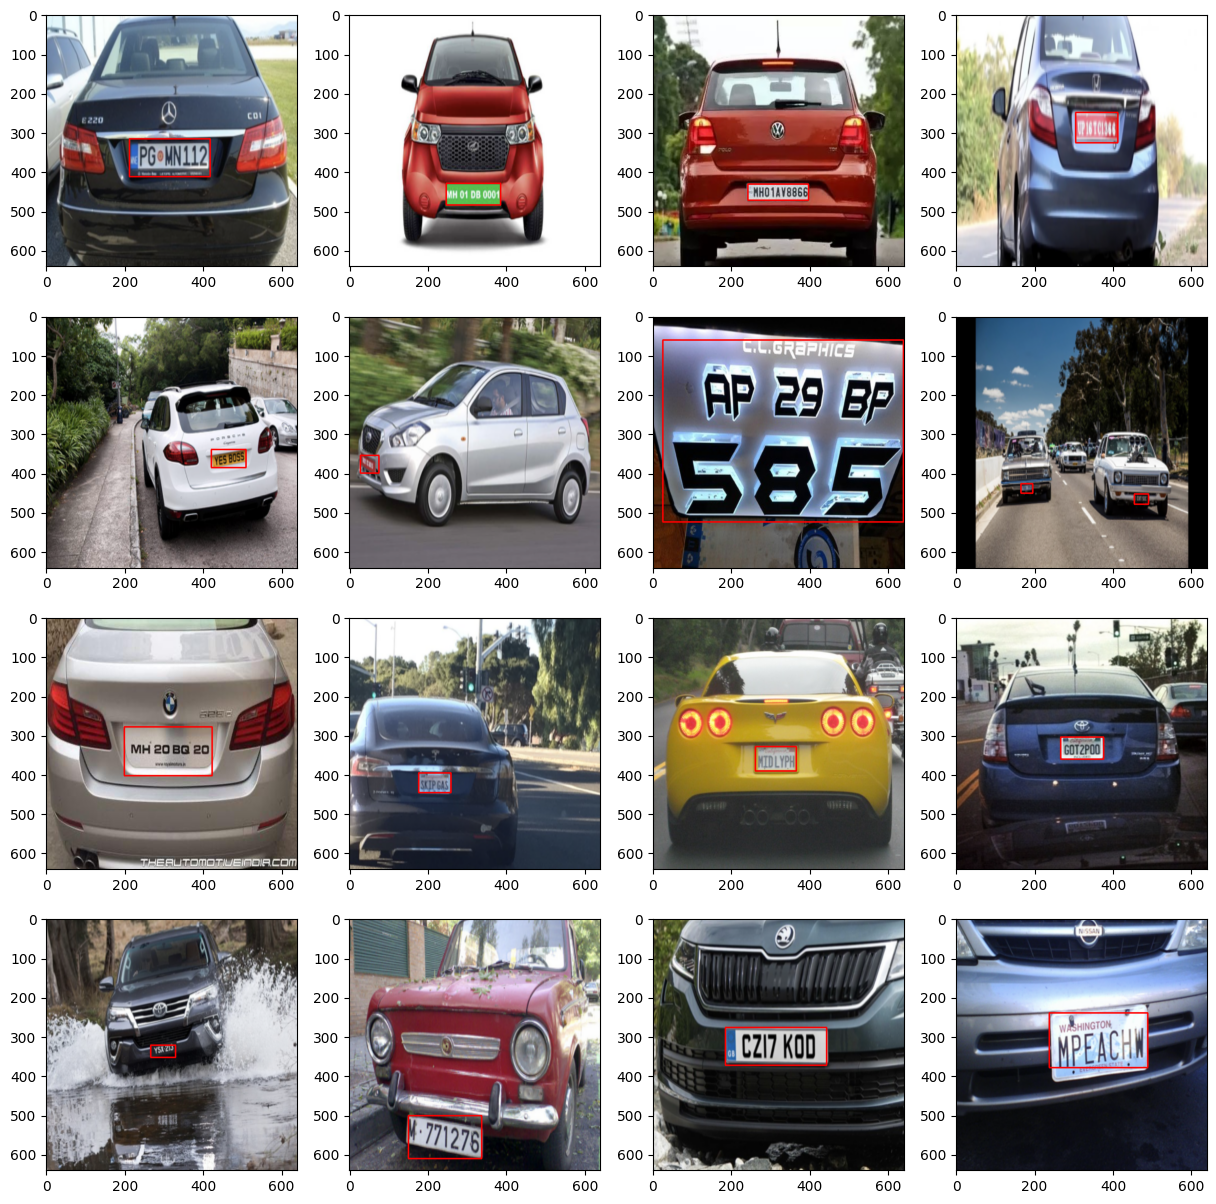

In [17]:
import random

# define the figure size
plt.figure(figsize=(15, 15))

# use the `plot_detections()` utility function to draw the ground truth boxes
random_samples = random.sample(range(len(ragged_images)), 16)
# print(f"Random samples: {random_samples}")

for i, idx in enumerate(random_samples):
    plt.subplot(4, 4, i+1)

    print(ragged_boxes[idx])
    plot_detections(
      image_np=ragged_images[idx].numpy().astype(np.uint8),
      boxes=ragged_boxes[idx],
      classes=ragged_classes[idx],
      scores=None, 
      category_index=category_index)

In [18]:
    # # apply offset to to have zero-indexed ground truth classes
    # zero_indexed_groundtruth_classes = tf.convert_to_tensor(
    #     np.ones(shape=[bbox.shape[0]], dtype=np.int32) - label_id_offset
    # )
    # # do one-hot encoding to ground truth classes
    # gt_classes_one_hot_tensors.append(
    #     tf.one_hot(zero_indexed_groundtruth_classes, num_classes)
    #     )

In [19]:
label_map = {
    'licence':1
}

prepare_train_dataset = AnnotationProcessor(annotation_file=XML_ANNOT_DIR_PATH)

image_paths, classes, boxes  = prepare_train_dataset.process_annotations_xml(image_dir=TRAIN_IMG_DIR, label_map=label_map,plot=False)

100%|██████████| 200/200 [00:00<00:00, 13791.16it/s]

In [20]:
ragged_bbox = tf.ragged.constant(boxes, dtype=tf.float32)
ragged_classes = tf.ragged.constant(classes)
ragged_image_paths = tf.ragged.constant(image_paths)

In [21]:
train_data = tf.data.Dataset.from_tensor_slices(
    (ragged_image_paths, ragged_classes, ragged_bbox)
)
train_data

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), RaggedTensorSpec(TensorShape([None]), tf.int32, 0, tf.int64), RaggedTensorSpec(TensorShape([None, None]), tf.float32, 1, tf.int64))>

In [22]:
for img, cls, bbs in train_data.take(1):
    print(img, cls, bbs)
    break

tf.Tensor(b'datasets/car-plate-detection/images/Cars321.png', shape=(), dtype=string) tf.Tensor([1], shape=(1,), dtype=int32) <tf.RaggedTensor [[0.5875, 0.4451827, 0.615, 0.5614618]]>


In [23]:
def load_image_into_tf_tensor(path):
    """Load an image from file into a numpy array.

    Puts image into numpy array to feed into tensorflow graph.
    Note that by convention we put it into a numpy array with shape
    (height, width, channels), where channels=3 for RGB.

    Args:
    path: a file path.

    Returns:
    uint8 numpy array with shape (img_height, img_width, 3)
    """
    # Read image
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    return tf.image.resize(image, (640, 640))

def load_dataset(image_path, classes, bbox):
    image = load_image_into_tf_tensor(image_path)
    zero_indexed_groundtruth_classes = tf.convert_to_tensor(
    classes - 1
    )
    one_label= tf.one_hot(zero_indexed_groundtruth_classes, num_classes)
    return image, one_label, bbox

In [24]:
train_ds = train_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)

In [25]:
train_ds = train_ds\
        .shuffle(buffer_size = len(image_paths)).batch(cfg.TRAIN.BATCH_SIZE)

In [26]:

for batch_num, (images, gt_classes, gt_boxes) in enumerate(train_ds):
    print(images, gt_classes, gt_boxes)
    break

tf.Tensor(
[[[[ 72.         84.         42.       ]
   [102.625     112.4375     53.8125   ]
   [141.25      148.         67.5625   ]
   ...
   [197.6875    211.6875    221.6875   ]
   [205.3125    219.875     229.875    ]
   [211.        226.        236.       ]]

  [[ 77.282814   89.4086     42.88047  ]
   [105.10132   115.039604   53.207176 ]
   [140.18872   147.0645     65.196236 ]
   ...
   [200.32104   214.20312   224.19527  ]
   [207.03413   221.4001    231.32935  ]
   [212.00626   226.75468   236.6289   ]]

  [[ 94.80469   107.34766    45.80078  ]
   [113.3147    123.670166   51.199463 ]
   [136.6687    143.96167    57.3479   ]
   ...
   [209.05591   222.54688   232.51294  ]
   [212.74438   226.4585    236.15308  ]
   [215.34375   229.25781   238.71484  ]]

  ...

  [[ 99.80078   103.34375   104.88672  ]
   [ 96.98779   100.29321   102.27368  ]
   [ 94.05859    97.05859    99.60156  ]
   ...
   [  0.          1.          0.       ]
   [  0.          1.          0.       ]
   [ 